# Problem: relativity

Where Newton is not enough, and by how much. Two real datasets and the
simulations that calibrate what can be claimed from them.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1 · Mercury's perihelion, by direct integration

The orbit equation for a test particle around a Schwarzschild mass is

$$\frac{d^2u}{d\phi^2} + u = \frac{GM}{h^2} + \frac{3GM}{c^2}u^2 ,\qquad u = 1/r$$

The last term is the whole of general relativity as far as planetary orbits go.
Switch it off and the ellipse closes; switch it on and it precesses. The
simulation is run **both ways** and the precession is the difference, so the
numerical bias common to both cancels.

In [2]:
m = load_json("relativity", "problem_meta")
mp = m["simulations"]["mercury_precession"]
print(f"simulated GR precession : {mp['precession_arcsec_per_century']:.4f} arcsec/century")
print(f"analytic 6 pi GM/(c^2 a(1-e^2)) : {mp['analytic_arcsec_per_century']:.4f}")
print(f"Newtonian control       : {mp['control_fraction_of_signal']:.2e} of the signal")
display(load_table("relativity","precession_vs_boost"))

simulated GR precession : 42.9807 arcsec/century
analytic 6 pi GM/(c^2 a(1-e^2)) : 42.9807
Newtonian control       : 2.98e-03 of the signal


,gr_boost,measured_rad,analytic_rad,ratio
0,1.0,5.029654e-07,5.018664e-07,1.002190
1,100.0,5.018875e-05,5.018664e-05,1.000042
2,1000.0,5.019685e-04,5.018664e-04,1.000203
3,10000.0,5.028781e-03,5.018664e-03,1.002016
4,100000.0,5.122023e-02,5.018664e-02,1.020595


The real effect is 5×10⁻⁷ radians per orbit and completely invisible on a plot,
so the animation multiplies the GR term by 4×10⁴. The exaggeration is stated
on the figure.

In [3]:
display(gif("relativity/schwarzschild_precession.gif", 460))
ld = m["simulations"]["light_deflection"]
print(f"Light bending at the solar limb:")
print(f"  general relativity, 4GM/c^2b : {ld['deflection_gr_arcsec']:.4f} arcsec")
print(f"  numerically integrated null geodesic : {ld['deflection_numeric_arcsec']:.4f} arcsec")
print(f"  Newtonian (half)             : {ld['deflection_newtonian_arcsec']:.4f} arcsec")

Light bending at the solar limb:
  general relativity, 4GM/c^2b : 1.7512 arcsec
  numerically integrated null geodesic : 1.7548 arcsec
  Newtonian (half)             : 0.8756 arcsec


## 2 · The same 43 arcsec, from the real ephemeris

Completely independent route: Mercury's acceleration is differentiated out of
JPL DE441, every planet's pull is subtracted using real positions, and what is
left is fitted for the coefficient of the 1PN Schwarzschild term. General
relativity says `alpha = 1`.

In [4]:
gm = load_json("relativity/mercury", "meta")
gr = gm["gr"]
lad = gr["residual_ladder"]
display(gif("relativity/mercury/gr_residual_ladder.png", 560))
print(f"alpha = {gr['alpha_GR']:.6f} +- {gr['alpha_sigma']:.6f}   (Einstein: 1)")
print(f"implied precession = {gr['precession_arcsec_cy']:.3f} arcsec/century")
print(f"GM_sun to {gr['GM_rel_error_ppb']:+.2f} ppb")
print()
print("two independent routes to the same number:")
print(f"   simulated Schwarzschild orbit : {mp['precession_arcsec_per_century']:.3f}")
print(f"   real JPL ephemeris            : {gr['precession_arcsec_cy']:.3f}")

alpha = 1.000121 +- 0.000017   (Einstein: 1)
implied precession = 42.985 arcsec/century
GM_sun to +0.22 ppb

two independent routes to the same number:
   simulated Schwarzschild orbit : 42.981
   real JPL ephemeris            : 42.985


### The warning this track earned

The GR term is 8×10⁻⁸ of Mercury's acceleration. At a 3-hour step with a
4th-order derivative, the *truncation error of the derivative* is a few ×10⁻⁹
and lands almost entirely in `alpha`.

In [5]:
display(pd.DataFrame(gm["gr_convergence"]))
display(gif("relativity/mercury/gr_convergence.png", 600,
            "run once at 180m/order 4 and stopped, this would have been a "
            "confident 56-sigma refutation of general relativity"))

,GM_rel_error_ppb,alpha_GR,alpha_sigma,fd_order,n_epochs,residual_after_gr,step
0,162.798813,3.149887,0.054472,4,801,3.860631e-08,360m
1,68094.946871,1065.686178,7.637714,2,1607,2.123070e-05,180m
2,10.371270,1.134343,0.002404,4,1605,2.500545e-09,180m
3,0.219765,1.000121,0.000017,6,1603,2.086233e-10,180m
4,0.852307,1.008484,0.000106,4,3213,2.670090e-10,90m
5,0.218050,1.000099,0.000013,6,3211,2.087557e-10,90m


## 3 · GW150914: the real strain

32 s of real 4096 Hz strain from both LIGO detectors, whitened, band-passed,
L1 inverted and delayed 6.9 ms, coherently summed. The instantaneous frequency
is measured **model-free** from sub-sample zero crossings — no waveform is
assumed, so fitting an inspiral law to it is not circular.

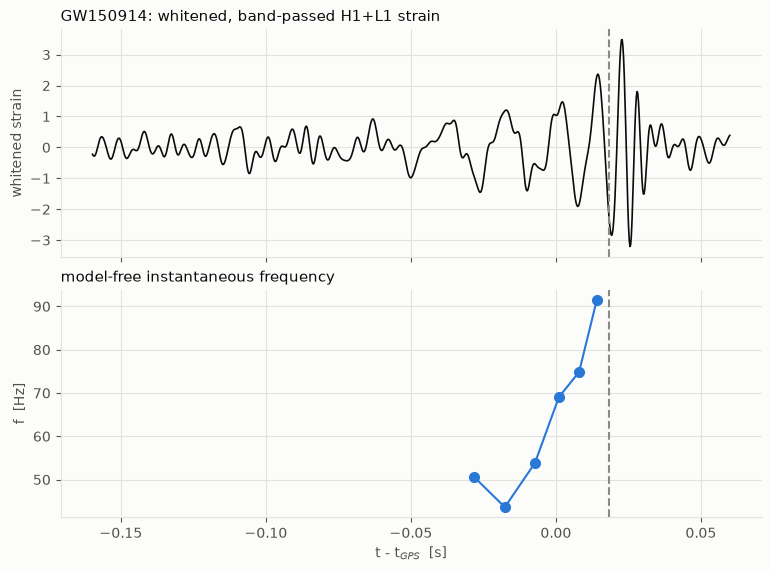

6 usable cycles; merger (envelope peak) at 18.2 ms


In [6]:
from physprior.data.sources import gwosc as gw
tr = gw.frequency_track()
fig, axes = plt.subplots(2,1, figsize=(7.6,5.6), sharex=True)
w = (tr.strain_t>-0.16)&(tr.strain_t<0.06)
axes[0].plot(tr.strain_t[w], tr.strain_h[w], color=P.INK, lw=1.2)
axes[0].axvline(tr.t_peak_s, color=P.INK_MUTED, ls="--", lw=1.5)
P._style(axes[0], "GW150914: whitened, band-passed H1+L1 strain", None, "whitened strain")
axes[1].plot(tr.t_s, tr.f_hz, "o", color=P.ARM_COLOR["physics"], ls="-", lw=1.5)
axes[1].axvline(tr.t_peak_s, color=P.INK_MUTED, ls="--", lw=1.5)
P._style(axes[1], "model-free instantaneous frequency", "t - t$_{GPS}$  [s]", "f  [Hz]")
plt.show()
print(f"{len(tr)} usable cycles; merger (envelope peak) at {tr.t_peak_s*1e3:.1f} ms")

### Laid over a simulated waveform at the published chirp mass — no fitting

In [7]:
display(gif("relativity/real_vs_simulated_chirp.png", 620))

## 4 · How much physics belongs in the loss?

Same points, same fitter, same two free parameters. The only thing that
changes is the post-Newtonian order of the law in the residual.

In [8]:
gwm = load_json("relativity/gw150914", "meta")
ab = pd.DataFrame(gwm["pn_ablation"])
display(ab[["label","Mc","Mc_sigma","bias_Msun","bias_sigma","rmse_hz","converged"]])
display(gif("relativity/gw150914/pn_ablation.png", 600))

,label,Mc,Mc_sigma,bias_Msun,bias_sigma,rmse_hz,converged
0,0PN (Newtonian),40.074950,4.057243,8.900950,2.193842,4.086628,True
1,1PN,200.000000,710.212172,168.826000,0.237712,114.342126,False
2,1.5PN (+tail),31.965578,2.779950,0.791578,0.284745,4.230163,True
3,2PN,30.754713,2.634620,-0.419287,-0.159145,4.253696,True


The RMSE barely moves across these rows while the recovered mass moves by
9 M☉. **Goodness of fit does not diagnose a wrong law.**

## 5 · Is that bias real, or is it the pipeline's?

The only way to know is to inject a waveform with a **known** chirp mass into
the **real detector noise** and push it through byte-for-byte the same
extraction and fitting code.

In [9]:
inj = m["discovery"]["injection"]
print(f"injected Mc = {inj['mchirp_true']:.2f} M_sun, "
      f"{inj['n_usable']}/{inj['n_trials']} usable, "
      f"SNR threshold {inj['snr_threshold']}")
for k in ("pn0","pn3"):
    if k in inj:
        d = inj[k]
        print(f"  {k}: median {d['median_Mc']:6.2f}  bias {d['bias_pct']:+6.1f}%  "
              f"scatter {d['scatter_Msun']:.2f}")
print()
print("compare with the REAL event:")
for r in gwm["pn_ablation"]:
    if r.get("converged") and r["pn_order"] in (0,3):
        print(f"  pn{r['pn_order']}: {r['Mc']:6.2f}  "
              f"bias {r['bias_Msun']/gwm['published_Mc_detector']*100:+6.1f}%")

injected Mc = 31.17 M_sun, 8/8 usable, SNR threshold 3.0
  pn0: median  39.03  bias  +25.2%  scatter 4.61
  pn3: median  30.79  bias   -1.2%  scatter 2.94

compare with the REAL event:
  pn0:  40.07  bias  +28.6%
  pn3:  30.75  bias   -1.3%


**The injection reproduces the real event's bias pattern.** The +25% at
Newtonian order is post-Newtonian truncation, not an artefact of the
extraction; and the 2PN answer is unbiased to about 1%.

### The threshold was calibrated on injections, never on the real event

The cycle-acceptance SNR cut was originally set to 2.0 *a priori*. Injections
show that at 2.0 the extraction admits noise-induced extra zero crossings that
read as 200 Hz where the truth is 40 Hz, and a known 31.2 M☉ comes back as 9.3.

In [10]:
tc = load_table("relativity","threshold_calibration")
display(tc)
print("the value adopted is the smallest whose injection bias is under 1%")

,snr_threshold,n_seeds,n_usable,n_failed,median_cycles,median_Mc,bias_pct,scatter_Msun,frac_within_20pct
0,2.0,10,10,0,10.0,9.315789,-70.116800,5.549599,0.0
1,2.5,10,10,0,7.0,29.401722,-5.685116,10.905653,0.6
2,3.0,10,10,0,5.0,30.902524,-0.870840,3.013100,0.9
3,3.5,10,5,5,5.0,33.162047,6.377259,2.711457,1.0
4,4.0,10,0,10,NaN,NaN,NaN,NaN,0.0


the value adopted is the smallest whose injection bias is under 1%
